### Task 1 — Repository Setup

Fork this repository and clone it. Verify the folder structure matches what's described in the main [README](../README.md). Install dependencies with `pip install -r requirements.txt`.  

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


### Task 2 — API Exploration

In `notebooks/day_01_exploration.ipynb`: 

1. **Make your first API call.** Fetch one year of daily historical data for Baku (latitude 40.41, longitude 49.87). Print the response structure and identify all available fields.   

In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 39.7756,
	"longitude": 47.6186,
	"start_date": "2025-04-19",
	"end_date": "2026-04-19",
	"daily": ["temperature_2m_mean", "temperature_2m_max", "sunshine_duration", "precipitation_sum", "wind_speed_10m_max", "et0_fao_evapotranspiration_sum", "temperature_2m_min", "soil_temperature_0_to_7cm_mean"],
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(4).ValuesAsNumpy()
daily_et0_fao_evapotranspiration_sum = daily.Variables(5).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(6).ValuesAsNumpy()
daily_soil_temperature_0_to_7cm_mean = daily.Variables(7).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["et0_fao_evapotranspiration_sum"] = daily_et0_fao_evapotranspiration_sum
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["soil_temperature_0_to_7cm_mean"] = daily_soil_temperature_0_to_7cm_mean

historical_beylagan = pd.DataFrame(data = daily_data)
print("\nBeylagan\n", historical_beylagan) 

Coordinates: 39.82425308227539°N 47.6323127746582°E
Elevation: 61.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                           date  temperature_2m
0    2025-04-19 00:00:00+00:00            6.25
1    2025-04-19 01:00:00+00:00            5.95
2    2025-04-19 02:00:00+00:00            5.50
3    2025-04-19 03:00:00+00:00            6.35
4    2025-04-19 04:00:00+00:00            9.05
...                        ...             ...
8779 2026-04-19 19:00:00+00:00           15.45
8780 2026-04-19 20:00:00+00:00           15.70
8781 2026-04-19 21:00:00+00:00           15.35
8782 2026-04-19 22:00:00+00:00           15.05
8783 2026-04-19 23:00:00+00:00           14.35

[8784 rows x 2 columns]

Beylagan
                          date  temperature_2m_mean  temperature_2m_max  \
0   2025-04-19 00:00:00+00:00            12.779168           19.400000   
1   2025-04-20 00:00:00+00:00            12.256249           17.950001   
2   2025-04-21 00:00:00+00:00            15.533336       

2. **Visualise a sample.** Plot the daily maximum temperature for the year. Note any gaps or anomalies.

In [5]:
import matplotlib.pyplot as plt

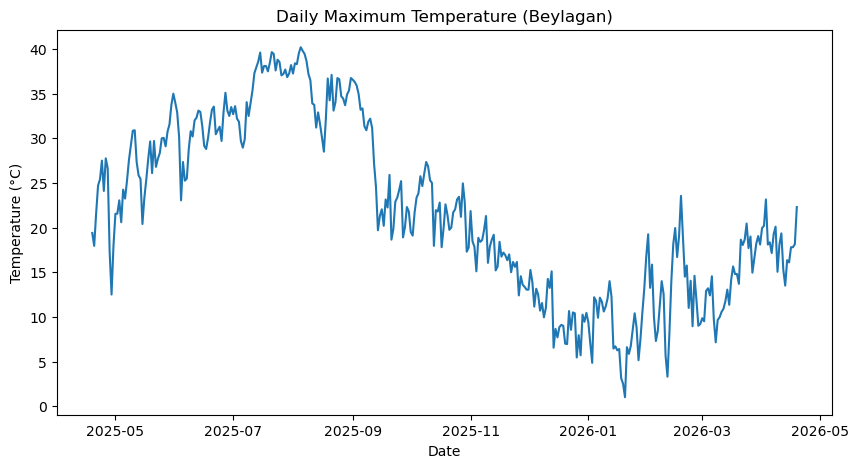

In [6]:
historical_beylagan["time"] = pd.to_datetime(historical_beylagan["date"])  
plt.figure(figsize=(10,5))
plt.plot(historical_beylagan["date"], historical_beylagan["temperature_2m_max"])
plt.title("Daily Maximum Temperature (Beylagan)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show() 

In [7]:
# I need to see if any month day contains any anomaliya or not

In [8]:
historical_beylagan["time"] = pd.to_datetime(historical_beylagan["time"])
historical_beylagan["year_month"] = historical_beylagan["time"].dt.to_period("M") 

C:\Users\User\AppData\Local\Temp\ipykernel_11092\1776938207.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  historical_beylagan["year_month"] = historical_beylagan["time"].dt.to_period("M")


In [9]:
monthly_stats = historical_beylagan.groupby("year_month").agg({
    "temperature_2m_max": "max",
    "temperature_2m_min": "min"
})

print(monthly_stats) 

            temperature_2m_max  temperature_2m_min
year_month                                        
2025-04              27.750000            5.500000
2025-05              35.000000            9.100000
2025-06              35.099998           15.400000
2025-07              39.650002           21.200001
2025-08              40.200001           19.700001
2025-09              36.549999           11.250000
2025-10              27.350000            6.950000
2025-11              21.850000            2.300000
2025-12              15.250000           -2.850000
2026-01              16.750000           -5.300000
2026-02              23.549999           -2.050000
2026-03              20.450001            0.150000
2026-04              23.150000            5.150000


In [10]:
# As you can see there is not any anomalies or nans. We have demonstrated it with the help of visualization and some code lines.
# Some small fluctuations are visible, no major gaps detected in the time series.

3. **Try the forecast endpoint.** Fetch the current 7-day forecast for the same city. Compare the response structure to the historical endpoint.

In [11]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 39.7756,
	"longitude": 47.6186,
	"daily": ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean", "sunshine_duration", "precipitation_sum", "wind_speed_10m_max", "et0_fao_evapotranspiration_sum"],
	"hourly": "temperature_2m",
	"past_days": 0,
	"forecast_days": 7,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_mean = daily.Variables(2).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(3).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(4).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(5).ValuesAsNumpy()
daily_et0_fao_evapotranspiration_sum = daily.Variables(6).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["et0_fao_evapotranspiration_sum"] = daily_et0_fao_evapotranspiration_sum

forecast_beylagan = pd.DataFrame(data = daily_data)
print("\nDaily data\n", forecast_beylagan) 

Coordinates: 39.75°N 47.625°E
Elevation: 61.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                          date  temperature_2m
0   2026-04-20 00:00:00+00:00       13.969500
1   2026-04-20 01:00:00+00:00       13.519500
2   2026-04-20 02:00:00+00:00       13.219500
3   2026-04-20 03:00:00+00:00       13.219500
4   2026-04-20 04:00:00+00:00       13.719500
..                        ...             ...
163 2026-04-26 19:00:00+00:00       14.111500
164 2026-04-26 20:00:00+00:00       13.411500
165 2026-04-26 21:00:00+00:00       12.861500
166 2026-04-26 22:00:00+00:00       12.361500
167 2026-04-26 23:00:00+00:00       12.011499

[168 rows x 2 columns]

Daily data
                        date  temperature_2m_max  temperature_2m_min  \
0 2026-04-20 00:00:00+00:00           17.269501           10.769500   
1 2026-04-21 00:00:00+00:00           11.969500            8.369500   
2 2026-04-22 00:00:00+00:00           20.819500            8.669499   
3 2026-04-23 00:00:00+00:00 

| Feature     | Historical         | Forecast               |
| ----------- | ------------------ | ---------------------- |
| Data source | Past weather       | Predicted weather      |
| Time range  | 1 year             | 7 days                 |
| Accuracy    | Real measured data | Model-based prediction |

4. **Experiment with parameters.** Add at least 3 more weather variables (e.g., precipitation, wind speed, humidity). Document what each variable represents and its unit. 

In [12]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 39.7756,
	"longitude": 47.6186,
	"start_date": "2025-04-19",
	"end_date": "2026-04-19",
	"daily": ["temperature_2m_mean", "temperature_2m_max", "sunshine_duration", "precipitation_sum", "wind_speed_10m_max", "et0_fao_evapotranspiration_sum", "temperature_2m_min", "soil_temperature_0_to_7cm_mean", "soil_moisture_0_to_7cm_mean", "relative_humidity_2m_mean", "shortwave_radiation_sum"],
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(4).ValuesAsNumpy()
daily_et0_fao_evapotranspiration_sum = daily.Variables(5).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(6).ValuesAsNumpy()
daily_soil_temperature_0_to_7cm_mean = daily.Variables(7).ValuesAsNumpy()
daily_soil_moisture_0_to_7cm_mean = daily.Variables(8).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(9).ValuesAsNumpy()
daily_shortwave_radiation_sum = daily.Variables(10).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["et0_fao_evapotranspiration_sum"] = daily_et0_fao_evapotranspiration_sum
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["soil_temperature_0_to_7cm_mean"] = daily_soil_temperature_0_to_7cm_mean
daily_data["soil_moisture_0_to_7cm_mean"] = daily_soil_moisture_0_to_7cm_mean
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["shortwave_radiation_sum"] = daily_shortwave_radiation_sum

data_beylagan_updated = pd.DataFrame(data = daily_data)
print("\nDaily data\n", data_beylagan_updated) 

Coordinates: 39.82425308227539°N 47.6323127746582°E
Elevation: 61.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                           date  temperature_2m
0    2025-04-19 00:00:00+00:00            6.25
1    2025-04-19 01:00:00+00:00            5.95
2    2025-04-19 02:00:00+00:00            5.50
3    2025-04-19 03:00:00+00:00            6.35
4    2025-04-19 04:00:00+00:00            9.05
...                        ...             ...
8779 2026-04-19 19:00:00+00:00           15.45
8780 2026-04-19 20:00:00+00:00           15.70
8781 2026-04-19 21:00:00+00:00           15.35
8782 2026-04-19 22:00:00+00:00           15.05
8783 2026-04-19 23:00:00+00:00           14.35

[8784 rows x 2 columns]

Daily data
                          date  temperature_2m_mean  temperature_2m_max  \
0   2025-04-19 00:00:00+00:00            12.779168           19.400000   
1   2025-04-20 00:00:00+00:00            12.256249           17.950001   
2   2025-04-21 00:00:00+00:00            15.533336     

| Variable                              | Unit                                                  | What it represents                                                | Why it is important                                                             |
| ------------------------------------- | ----------------------------------------------------- | ----------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| **daily_shortwave_radiation_sum**     | MJ/m² (megajoules per square meter)                   | Total amount of solar energy received at the surface during a day | Drives photosynthesis and plant growth; more radiation = more energy for crops  |
| **daily_relative_humidity_2m_mean**   | % (percentage)                                        | Average air humidity at 2 meters above ground                     | Affects plant transpiration and risk of diseases (e.g., fungi in high humidity) |
| **daily_soil_moisture_0_to_7cm_mean** | m³/m³ (cubic meters of water per cubic meter of soil) | Average water content in the top 0–7 cm soil layer                | Critical for seed germination and early plant growth                            |


### Task 3 — City & Variable Selection 

Choose your 3+ cities and document: 

| City | Latitude | Longitude | Why this city? | 
|------|----------|-----------|----------------| 
| Baku | 40.41 | 49.87 | Home city, local relevance | 
| ... | ... | ... | ... | 

Choose at least **6 daily weather variables** you will track. For each variable, note: name, unit, and why it is relevant to your analysis. 

| Variable                    | Unit  | Why it is relevant                                               |
| --------------------------- | ----- | ---------------------------------------------------------------- |
| temperature_2m_max          | °C    | Measures daily heat stress affecting crop growth and yield       |
| temperature_2m_min          | °C    | Important for frost detection and plant survival conditions      |
| precipitation_sum           | mm    | Direct indicator of water availability for crops                 |
| soil_moisture_0_to_7cm_mean | m³/m³ | Shows water availability in root zone (critical for germination) |
| relative_humidity_2m_mean   | %     | Impacts plant transpiration and disease risk (fungal growth)     |
| wind_speed_10m_max          | m/s   | Affects evaporation rate and can physically damage crops         | 

| City      | Latitude | Longitude | Why this city?                                                                          |
| --------- | -------- | --------- | --------------------------------------------------------------------------------------- |
| Beylagan  | 39.77    | 47.62     | Major agricultural region with irrigation-based farming and crop production             |
| Imishli   | 39.87    | 48.06     | Known for grain and cotton production, representative of central lowland agriculture    |
| Saatli    | 39.93    | 48.37     | Strong agricultural activity, especially in crop cultivation under semi-arid conditions |
| Sabirabad | 40.01    | 48.48     | Located in Kura-Araz lowland, important for large-scale farming and irrigation systems  | 

### Task 4 — Project Plan

Update the `README.md` in your fork with: 

- **Problem statement**: What question will your prediction model try to answer? 
- **Data sources**: Which API endpoints and parameters you will use
- **Cities and variables**: Your selections from Task 3
- **Methodology outline**: High-level approach for each week 
- **Success criteria**: How will you evaluate your pipeline and your model?  

## Project Plan

### Problem Statement

The goal of this project is to investigate whether historical weather data can be used to reliably model and predict agricultural conditions relevant to cotton production.

Specifically, the project aims to answer the following question:

**“Can we predict temperature anomalies or crop-relevant environmental conditions based on historical weather patterns, and how reliable are these predictions given the quality of the data?”**

Rather than predicting exact crop yield (which requires external agricultural datasets), the focus is on modeling **weather-driven conditions** such as heat stress, water availability, and seasonal patterns that directly influence crop productivity.

This aligns with the broader project theme: *Can we trust this data?*

---

### Data Sources

All data will be collected from the **Open-Meteo API**, which provides free access to historical and forecast weather data.

Two endpoints will be used:

- **Historical Data (Archive API)**  
  Used to collect long-term daily weather data (5+ years) for each selected city  
  Example parameters:
  - temperature (mean, max, min)
  - precipitation
  - humidity
  - wind speed
  - solar radiation
  - soil moisture
  - evapotranspiration

- **Forecast Data (Forecast API)**  
  Used to retrieve 7-day weather forecasts for comparison with historical patterns and potential future prediction use cases

No API key is required, which ensures reproducibility and accessibility.

---

### Cities and Variables

#### Selected Cities

The following cities were selected:

- Saatli  
- Sabirabad  
- Imishli  
- Beylagan  
- Barda  

These cities are all located in the **central lowland agricultural region of Azerbaijan**, where cotton production is highly concentrated.

The selection strategy is intentional:

- These regions share **similar agricultural practices**, allowing the model to focus on meaningful environmental patterns rather than unrelated variability  
- At the same time, they exhibit **small differences in temperature, irrigation, and soil conditions**, which helps the model learn useful distinctions  
- The regions are known for **hot summers and irrigation-based farming**, making them ideal for studying heat stress and water-related variables  

This creates a balance between **consistency (for learning patterns)** and **variation (for model robustness)**.

---

#### Selected Weather Variables

The selected variables aim to capture the most important environmental factors affecting crop growth:

- **Temperature (mean, max, min)**  
  Core driver of plant development and stress  
  Maximum temperature is especially important for detecting heat stress  

- **Precipitation (precipitation_sum)**  
  Indicates natural water input and irrigation needs  

- **Relative Humidity**  
  Affects plant health, transpiration, and disease risk  

- **Sunshine Duration & Shortwave Radiation**  
  Represent solar energy available for photosynthesis and biomass production  

- **Wind Speed**  
  Influences evaporation, water loss, and physical stress on crops  

- **Evapotranspiration (ET₀)**  
  A critical agricultural metric that estimates how much water is lost from soil and plants  
  Helps measure drought stress and irrigation demand  

- **Soil Moisture (top layer)**  
  Direct indicator of water availability for plant roots  

These variables were selected to represent four key dimensions:

1. Temperature conditions  
2. Water availability  
3. Solar energy  
4. Soil and atmospheric interactions  

Together, they provide a **comprehensive view of the agricultural environment**.

---

### Methodology

The project is divided into two main phases:

#### Week 1 — Data Engineering

Focus: Building a reliable data pipeline

- Collect historical weather data from the API  
- Structure and store data in a clean format  
- Perform data cleaning and validation  
- Identify missing values and inconsistencies  
- Conduct initial exploratory data analysis (EDA)  
- Create basic features (e.g., monthly averages, seasonal indicators)  

This phase ensures the dataset is accurate, consistent, and suitable for modeling.

---

#### Week 2 — Statistical Analysis & Prediction

Focus: Extracting insights and building models

- Perform statistical analysis (distributions, correlations)  
- Evaluate relationships between variables  
- Conduct hypothesis testing (e.g., seasonal differences)  
- Engineer advanced features (extreme events, variability)  
- Train predictive models:
  - Logistic Regression (baseline)
  - Random Forest (non-linear model)  
- Evaluate and compare model performance  
- Interpret results and assess reliability  

This phase focuses on understanding patterns and building predictive capability.

---

### Success Criteria

The project will be considered successful if:

- The model achieves **strong predictive performance**  
  (e.g., Accuracy > 0.75 and a balanced F1 Score)

- The analysis identifies **meaningful relationships** between weather variables and agricultural conditions  

- The pipeline is:
  - clean  
  - reproducible  
  - well-structured  

- Data quality issues (missing values, anomalies, inconsistencies) are:
  - clearly identified  
  - properly handled  
  - critically evaluated  

- The final results provide **useful insights into how climate affects agricultural conditions**, even if perfect prediction is not achieved  

Ultimately, success is not only about model accuracy, but also about **understanding the reliability and limitations of the data**.